# Tugas Besar Data Mining  
# Identifikasi Risiko Dropout Mahasiswa Perguruan Tinggi
### Berdasarkan Faktor Akademik, Demografis, dan Sosial Ekonomi

**Dataset:** Student Dropout - UCI Machine Learning Repository  
**Sumber:** https://archive.uci.edu/dataset/697  

## 1. Import Library

Pada tahap ini saya mengimpor library yang dibutuhkan. `pandas` dan `numpy` dipakai untuk mengolah data, `matplotlib` dan `seaborn` untuk visualisasi, lalu `scikit-learn` untuk proses modeling.

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif
from sklearn.decomposition import PCA

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    mean_absolute_error, mean_squared_error, r2_score
)

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')

## 2. Data Identification

Di bagian ini dataset mulai dibaca dan dicek bentuk awalnya. Tujuannya untuk mengetahui jumlah baris, jumlah kolom, nama kolom, dan gambaran isi data secara umum

In [ ]:
file_path = "data.csv"

df = pd.read_csv(file_path, sep=';')

print("Dataset berhasil dibaca.")
print("Ukuran dataset:", df.shape)
print("\n5 data teratas:")
display(df.head())

print("\nInfo singkat dataset:")
df.info()

print("\nDaftar nama kolom:")
for i, col in enumerate(df.columns, 1):
    print(i, col)

Dataset berhasil dibaca.
Ukuran dataset: (4424, 37)

5 data teratas:


,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Admission grade,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,5,9,127.3,1,0,0,1,1,0,20,0,0,0,0,0,0.000000,0,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,3,3,142.5,1,0,0,0,1,0,19,0,0,6,6,6,14.000000,0,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,9,9,124.8,1,0,0,0,1,0,19,0,0,6,0,0,0.000000,0,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,5,3,119.6,1,0,0,1,0,0,20,0,0,6,8,6,13.428571,0,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,9,9,141.5,0,0,0,1,0,0,45,0,0,6,9,5,12.333333,0,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate



Info singkat dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance	                     4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualifica

In [ ]:
df.columns = (
    df.columns
    .str.strip()
    .str.replace("\t", "", regex=False)
    .str.replace(" ", "_")
    .str.replace("/", "_")
    .str.replace("(", "", regex=False)
    .str.replace(")", "", regex=False)
)

print("Nama kolom setelah dirapikan:")
print(df.columns.tolist())
display(df.head())

Nama kolom setelah dirapikan:
['Marital_status', 'Application_mode', 'Application_order', 'Course', 'Daytime_evening_attendance', 'Previous_qualification', 'Previous_qualification_grade', 'Nacionality', "Mother's_qualification", "Father's_qualification", "Mother's_occupation", "Father's_occupation", 'Admission_grade', 'Displaced', 'Educational_special_needs', 'Debtor', 'Tuition_fees_up_to_date', 'Gender', 'Scholarship_holder', 'Age_at_enrollment', 'International', 'Curricular_units_1st_sem_credited', 'Curricular_units_1st_sem_enrolled', 'Curricular_units_1st_sem_evaluations', 'Curricular_units_1st_sem_approved', 'Curricular_units_1st_sem_grade', 'Curricular_units_1st_sem_without_evaluations', 'Curricular_units_2nd_sem_credited', 'Curricular_units_2nd_sem_enrolled', 'Curricular_units_2nd_sem_evaluations', 'Curricular_units_2nd_sem_approved', 'Curricular_units_2nd_sem_grade', 'Curricular_units_2nd_sem_without_evaluations', 'Unemployment_rate', 'Inflation_rate', 'GDP', 'Target']


,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mother's_qualification,Father's_qualification,Mother's_occupation,Father's_occupation,Admission_grade,Displaced,Educational_special_needs,Debtor,Tuition_fees_up_to_date,Gender,Scholarship_holder,Age_at_enrollment,International,Curricular_units_1st_sem_credited,Curricular_units_1st_sem_enrolled,Curricular_units_1st_sem_evaluations,Curricular_units_1st_sem_approved,Curricular_units_1st_sem_grade,Curricular_units_1st_sem_without_evaluations,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,5,9,127.3,1,0,0,1,1,0,20,0,0,0,0,0,0.000000,0,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,3,3,142.5,1,0,0,0,1,0,19,0,0,6,6,6,14.000000,0,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,9,9,124.8,1,0,0,0,1,0,19,0,0,6,0,0,0.000000,0,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,5,3,119.6,1,0,0,1,0,0,20,0,0,6,8,6,13.428571,0,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,9,9,141.5,0,0,0,1,0,0,45,0,0,6,9,5,12.333333,0,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


Distribusi data pada kolom target:


,count
Target,
Graduate,2209
Dropout,1421
Enrolled,794


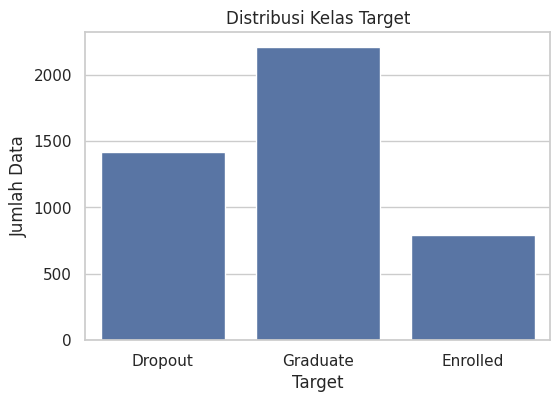

In [ ]:
# Kolom Target dipakai sebagai label utama untuk classification.
target_col = "Target"

print("Distribusi data pada kolom target:")
display(df[target_col].value_counts())

plt.figure(figsize=(6,4))
sns.countplot(data=df, x=target_col)
plt.title("Distribusi Kelas Target")
plt.xlabel("Target")
plt.ylabel("Jumlah Data")
plt.show()

## 3. Eksplorasi Awal & Deteksi Missing Value

In [ ]:
print("Jumlah duplikasi:", df.duplicated().sum())

missing_value = pd.DataFrame({
    "Kolom": df.columns,
    "Jumlah Missing": df.isnull().sum().values,
    "Persentase Missing (%)": (df.isnull().mean().values * 100).round(2)
})

display(missing_value.sort_values(by="Jumlah Missing", ascending=False))

Jumlah duplikasi: 0


,Kolom,Jumlah Missing,Persentase Missing (%)
0,Marital_status,0,0.0
1,Application_mode,0,0.0
2,Application_order,0,0.0
3,Course,0,0.0
4,Daytime_evening_attendance,0,0.0
5,Previous_qualification,0,0.0
6,Previous_qualification_grade,0,0.0
7,Nacionality,0,0.0
8,Mother's_qualification,0,0.0
9,Father's_qualification,0,0.0


## 4. Statistik Deskriptif Variabel Numerik

Pada bagian ini saya melihat ringkasan statistik dari kolom numerik, seperti rata-rata, nilai minimum, maksimum, dan sebaran datanya. Dari sini kita bisa membaca pola awal pada dataset

In [ ]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print("Jumlah kolom numerik:", len(numeric_cols))
print("Kolom numerik:", numeric_cols)

print("\nJumlah kolom kategorikal:", len(categorical_cols))
print("Kolom kategorikal:", categorical_cols)

print("\nStatistik deskriptif kolom numerik:")
display(df[numeric_cols].describe().T)

Jumlah kolom numerik: 36
Kolom numerik: ['Marital_status', 'Application_mode', 'Application_order', 'Course', 'Daytime_evening_attendance', 'Previous_qualification', 'Previous_qualification_grade', 'Nacionality', "Mother's_qualification", "Father's_qualification", "Mother's_occupation", "Father's_occupation", 'Admission_grade', 'Displaced', 'Educational_special_needs', 'Debtor', 'Tuition_fees_up_to_date', 'Gender', 'Scholarship_holder', 'Age_at_enrollment', 'International', 'Curricular_units_1st_sem_credited', 'Curricular_units_1st_sem_enrolled', 'Curricular_units_1st_sem_evaluations', 'Curricular_units_1st_sem_approved', 'Curricular_units_1st_sem_grade', 'Curricular_units_1st_sem_without_evaluations', 'Curricular_units_2nd_sem_credited', 'Curricular_units_2nd_sem_enrolled', 'Curricular_units_2nd_sem_evaluations', 'Curricular_units_2nd_sem_approved', 'Curricular_units_2nd_sem_grade', 'Curricular_units_2nd_sem_without_evaluations', 'Unemployment_rate', 'Inflation_rate', 'GDP']

Jumlah k

,count,mean,std,min,25%,50%,75%,max
Marital_status,4424.0,1.178571,0.605747,1.00,1.00,1.000000,1.000000,6.000000
Application_mode,4424.0,18.669078,17.484682,1.00,1.00,17.000000,39.000000,57.000000
Application_order,4424.0,1.727848,1.313793,0.00,1.00,1.000000,2.000000,9.000000
Course,4424.0,8856.642631,2063.566416,33.00,9085.00,9238.000000,9556.000000,9991.000000
Daytime_evening_attendance,4424.0,0.890823,0.311897,0.00,1.00,1.000000,1.000000,1.000000
Previous_qualification,4424.0,4.577758,10.216592,1.00,1.00,1.000000,1.000000,43.000000
Previous_qualification_grade,4424.0,132.613314,13.188332,95.00,125.00,133.100000,140.000000,190.000000
Nacionality,4424.0,1.873192,6.914514,1.00,1.00,1.000000,1.000000,109.000000
Mother's_qualification,4424.0,19.561935,15.603186,1.00,2.00,19.000000,37.000000,44.000000
Father's_qualification,4424.0,22.275316,15.343108,1.00,3.00,19.000000,37.000000,44.000000


## 5. Visualisasi Distribusi Data

Visualisasi dipakai supaya pola data lebih mudah dilihat. Di sini saya menampilkan distribusi beberapa fitur numerik penting dan boxplot untuk melihat kemungkinan outlier

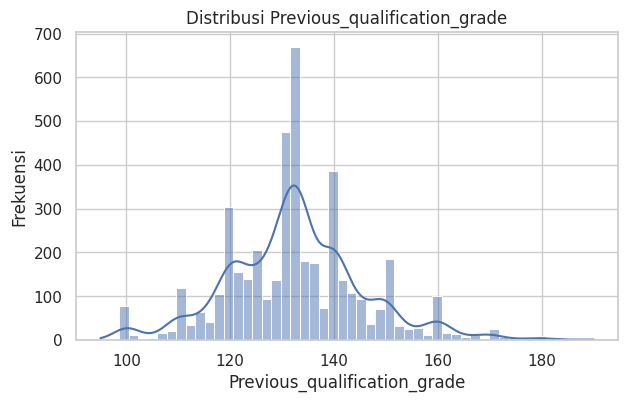

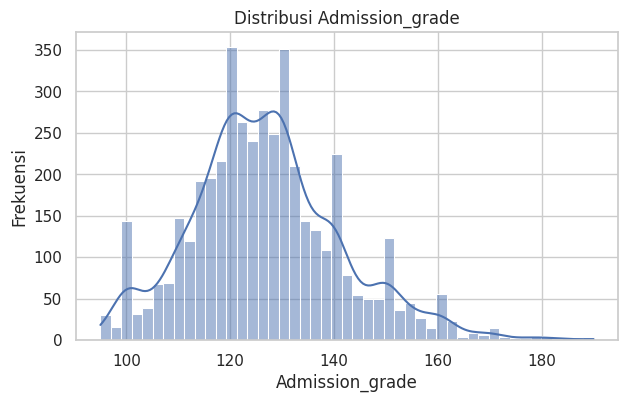

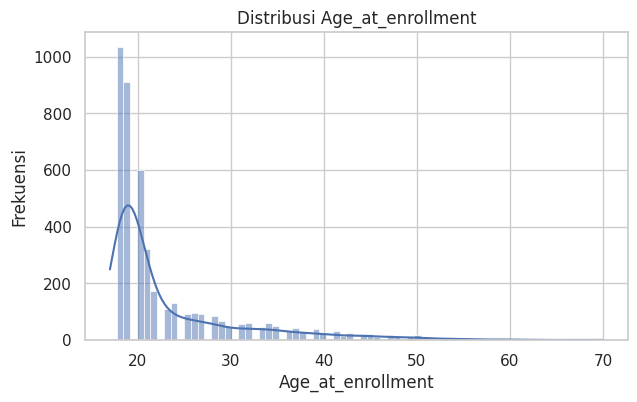

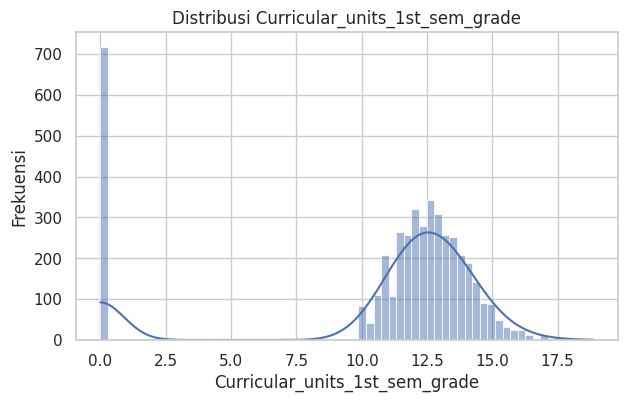

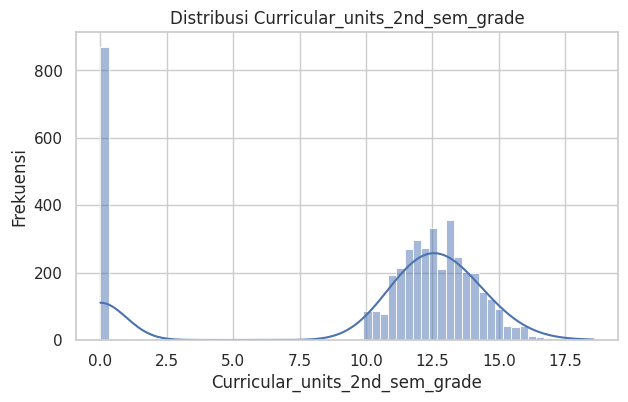

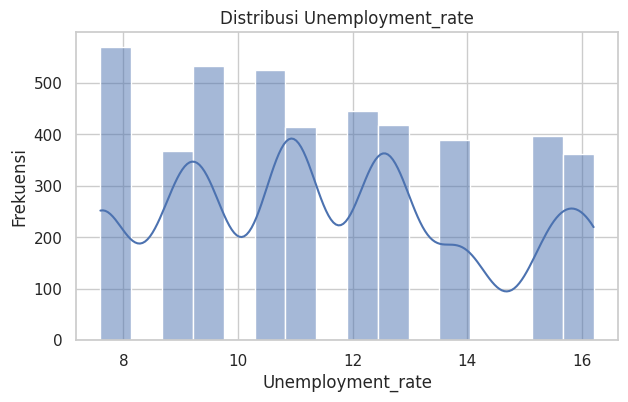

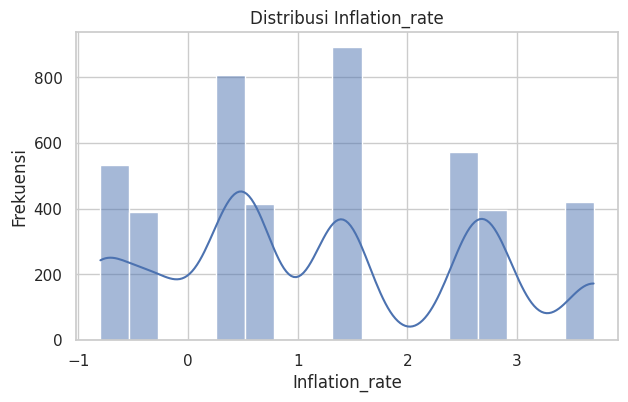

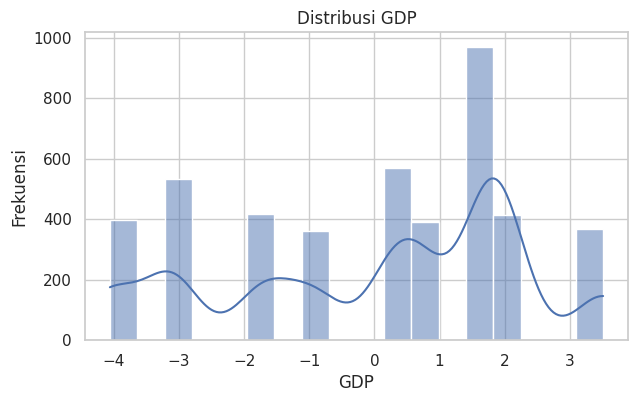

In [ ]:
selected_numeric_for_plot = [
    'Previous_qualification_grade',
    'Admission_grade',
    'Age_at_enrollment',
    'Curricular_units_1st_sem_grade',
    'Curricular_units_2nd_sem_grade',
    'Unemployment_rate',
    'Inflation_rate',
    'GDP'
]

selected_numeric_for_plot = [col for col in selected_numeric_for_plot if col in df.columns]

for col in selected_numeric_for_plot:
    plt.figure(figsize=(7,4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribusi {col}")
    plt.xlabel(col)
    plt.ylabel("Frekuensi")
    plt.show()

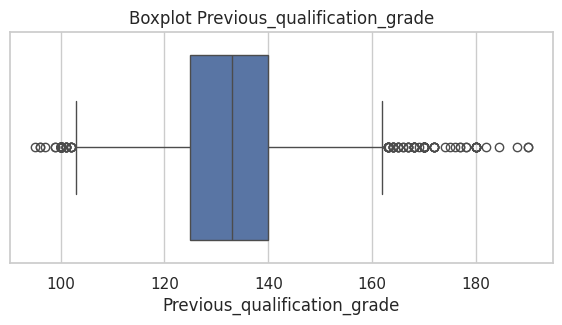

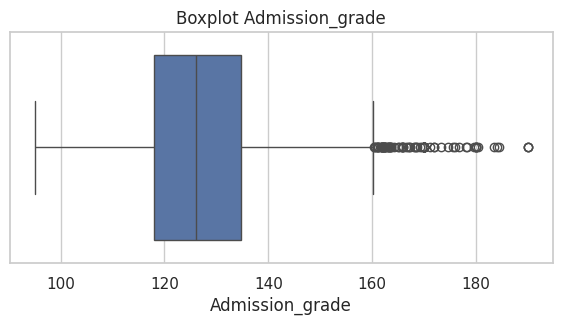

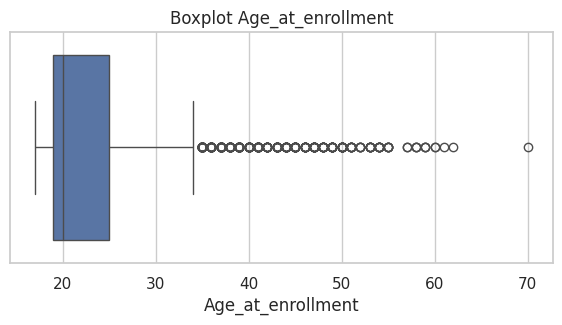

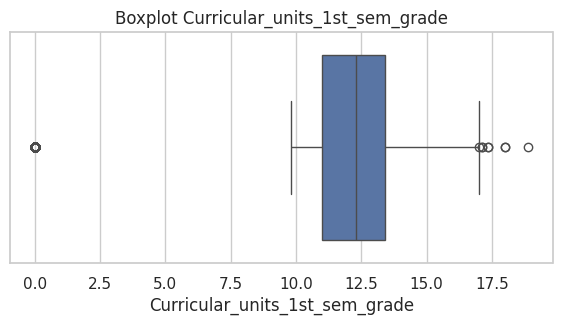

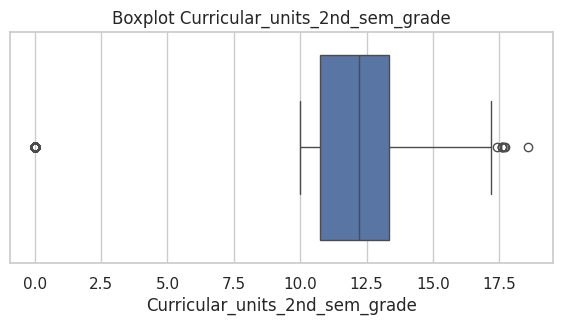

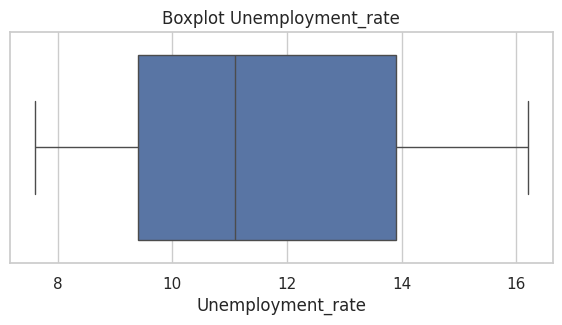

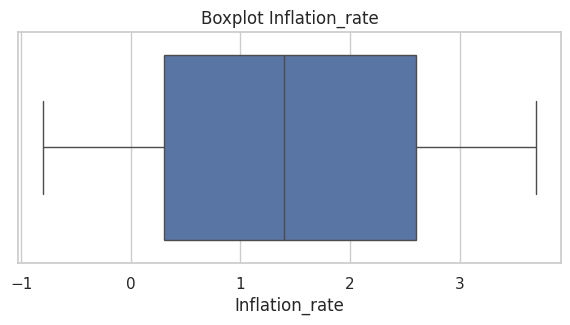

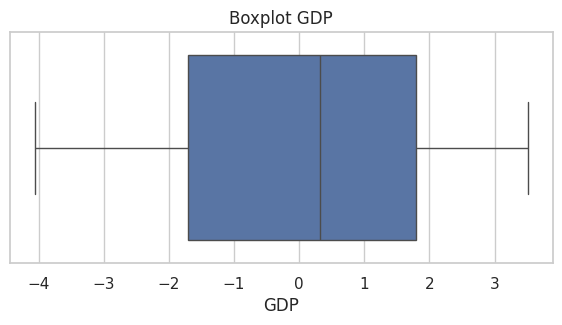

In [ ]:
# Boxplot dipakai untuk melihat apakah ada nilai yang terlalu jauh dari data lainnya
for col in selected_numeric_for_plot:
    plt.figure(figsize=(7,3))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot {col}")
    plt.show()

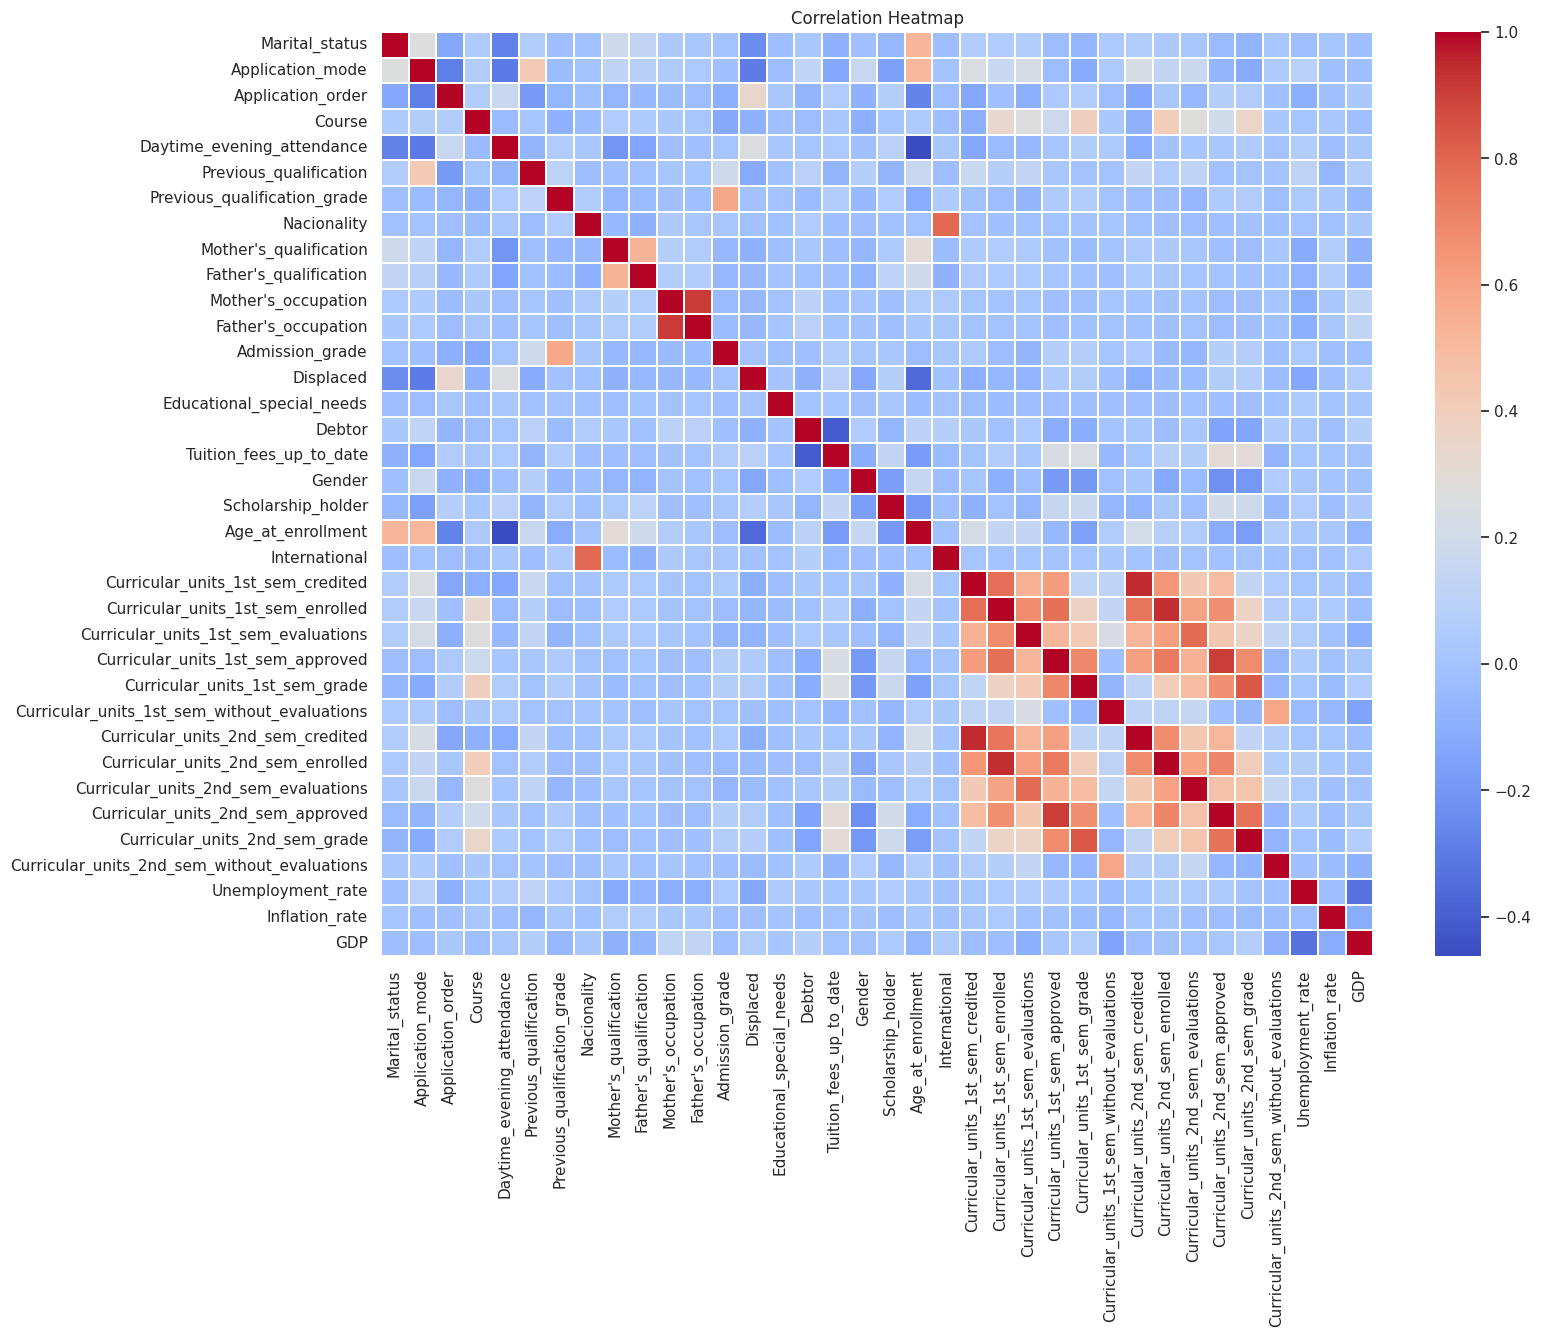

In [ ]:
# Heatmap korelasi membantu melihat hubungan antar fitur numerik.
plt.figure(figsize=(16,12))
corr = df[numeric_cols].corr()
sns.heatmap(corr, cmap='coolwarm', linewidths=0.3)
plt.title("Correlation Heatmap")
plt.show()

## 6. Data Cleaning

Tahap cleaning dilakukan supaya data lebih siap dipakai untuk modeling. Pada bagian ini data duplikat dihapus, missing value ditangani, dan beberapa nilai ekstrem dirapikan dengan teknik capping

In [ ]:
df_clean = df.copy()

# Data duplikat dihapus supaya tidak ada baris yang terhitung dua kali.
df_clean = df_clean.drop_duplicates()

# Missing value ditangani dengan cara sederhana: numerik pakai median, kategorikal pakai modus.
num_cols = df_clean.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df_clean.select_dtypes(include=['object']).columns

for col in num_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

for col in cat_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

print("Ukuran data sebelum cleaning:", df.shape)
print("Ukuran data setelah cleaning:", df_clean.shape)
print("Total missing setelah cleaning:", df_clean.isnull().sum().sum())

Ukuran data sebelum cleaning: (4424, 37)
Ukuran data setelah cleaning: (4424, 37)
Total missing setelah cleaning: 0


In [ ]:
# Untuk outlier, saya pakai metode IQR. Nilai yang terlalu ekstrem tidak langsung dibuang, tapi dibatasi dengan capping.

df_capped = df_clean.copy()

for col in selected_numeric_for_plot:
    Q1 = df_capped[col].quantile(0.25)
    Q3 = df_capped[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df_capped[col] = np.where(df_capped[col] < lower_bound, lower_bound, df_capped[col])
    df_capped[col] = np.where(df_capped[col] > upper_bound, upper_bound, df_capped[col])

print("Outlier handling dengan capping sudah selesai.")
display(df_capped.head())

Outlier handling dengan capping sudah selesai.


,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mother's_qualification,Father's_qualification,Mother's_occupation,Father's_occupation,Admission_grade,Displaced,Educational_special_needs,Debtor,Tuition_fees_up_to_date,Gender,Scholarship_holder,Age_at_enrollment,International,Curricular_units_1st_sem_credited,Curricular_units_1st_sem_enrolled,Curricular_units_1st_sem_evaluations,Curricular_units_1st_sem_approved,Curricular_units_1st_sem_grade,Curricular_units_1st_sem_without_evaluations,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,5,9,127.3,1,0,0,1,1,0,20.0,0,0,0,0,0,7.400000,0,0,0,0,0,6.875000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,3,3,142.5,1,0,0,0,1,0,19.0,0,0,6,6,6,14.000000,0,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,9,9,124.8,1,0,0,0,1,0,19.0,0,0,6,0,0,7.400000,0,0,6,0,0,6.875000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,5,3,119.6,1,0,0,1,0,0,20.0,0,0,6,8,6,13.428571,0,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,102.5,1,37,38,9,9,141.5,0,0,0,1,0,0,34.0,0,0,6,9,5,12.333333,0,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


## 7. Feature Selection

Pada tahap ini saya mencari fitur yang paling berpengaruh terhadap kolom target. Tujuannya agar model tidak memakai semua kolom secara asal, tetapi lebih fokus ke fitur yang kontribusinya lebih besar

,Feature,Score
30,Curricular_units_2nd_sem_approved,1410.732938
31,Curricular_units_2nd_sem_grade,1180.370458
24,Curricular_units_1st_sem_approved,859.866768
25,Curricular_units_1st_sem_grade,788.807324
16,Tuition_fees_up_to_date,505.621429
18,Scholarship_holder,225.751437
19,Age_at_enrollment,208.859960
15,Debtor,137.647527
17,Gender,123.041811
1,Application_mode,114.534956


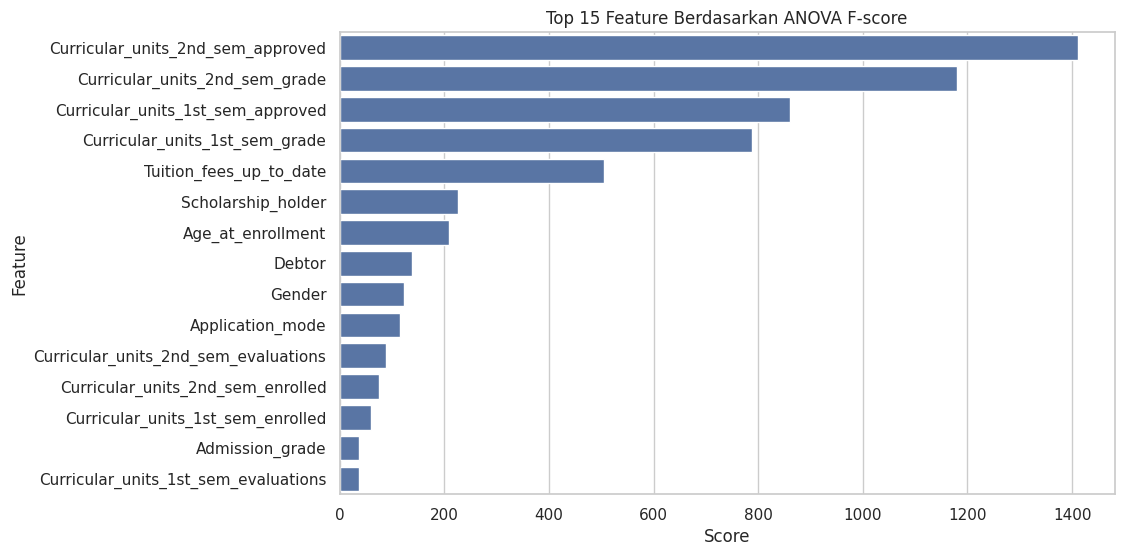

In [ ]:
# Target diubah dulu ke bentuk angka karena SelectKBest membutuhkan label numerik.
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(df_capped[target_col])

X_fs = df_capped.drop(columns=[target_col])

# Semua fitur selain target sudah berbentuk angka, jadi bisa langsung dipakai untuk feature selection.
selector = SelectKBest(score_func=f_classif, k='all')
selector.fit(X_fs, y_encoded)

feature_scores = pd.DataFrame({
    "Feature": X_fs.columns,
    "Score": selector.scores_
}).sort_values(by="Score", ascending=False)

display(feature_scores.head(15))

plt.figure(figsize=(10,6))
sns.barplot(data=feature_scores.head(15), x="Score", y="Feature")
plt.title("Top 15 Feature Berdasarkan ANOVA F-score")
plt.show()

,Feature,Importance
30,Curricular_units_2nd_sem_approved,0.143485
31,Curricular_units_2nd_sem_grade,0.115988
24,Curricular_units_1st_sem_approved,0.083897
25,Curricular_units_1st_sem_grade,0.058853
12,Admission_grade,0.042167
16,Tuition_fees_up_to_date,0.041569
29,Curricular_units_2nd_sem_evaluations,0.040421
6,Previous_qualification_grade,0.037489
19,Age_at_enrollment,0.036823
23,Curricular_units_1st_sem_evaluations,0.035939


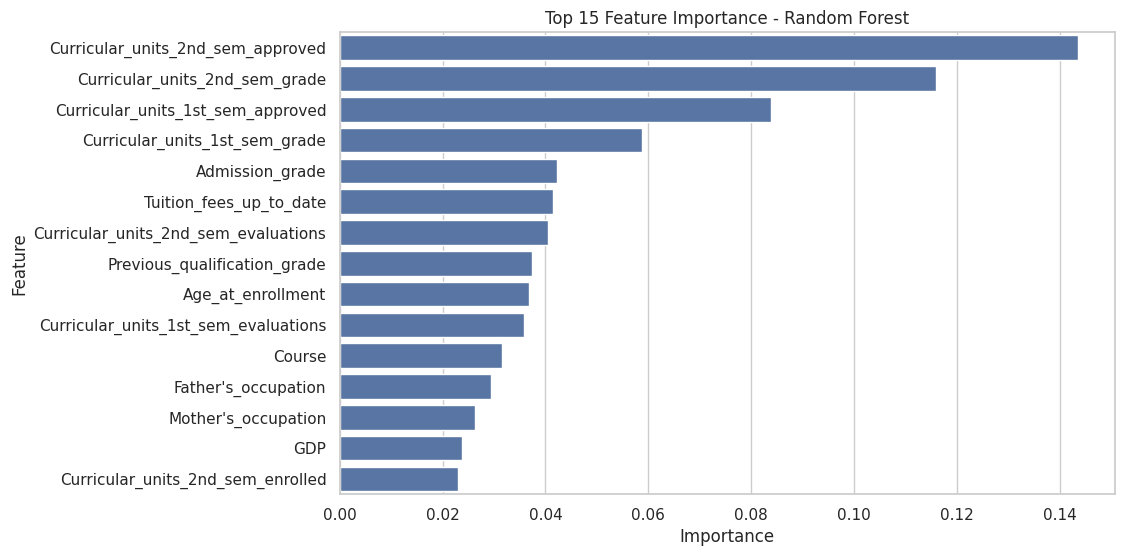

In [ ]:
# Feature importance dicek dengan Random Forest sebagai pembanding.
rf_temp = RandomForestClassifier(random_state=42)
rf_temp.fit(X_fs, y_encoded)

importance_df = pd.DataFrame({
    "Feature": X_fs.columns,
    "Importance": rf_temp.feature_importances_
}).sort_values(by="Importance", ascending=False)

display(importance_df.head(15))

plt.figure(figsize=(10,6))
sns.barplot(data=importance_df.head(15), x="Importance", y="Feature")
plt.title("Top 15 Feature Importance - Random Forest")
plt.show()

## 8. Data Selection

In [ ]:
# Fitur yang dipakai adalah 15 fitur teratas dari feature importance. Jumlah ini masih bisa disesuaikan jika dibutuhkan.
selected_features = importance_df.head(15)["Feature"].tolist()

print("Fitur yang dipilih untuk model:")
for f in selected_features:
    print("-", f)

X = df_capped[selected_features]
y = df_capped[target_col]

print("Preview fitur:")
display(X.head())

print("Preview target:")
display(y.head())

Fitur yang dipilih untuk model:
- Curricular_units_2nd_sem_approved
- Curricular_units_2nd_sem_grade
- Curricular_units_1st_sem_approved
- Curricular_units_1st_sem_grade
- Admission_grade
- Tuition_fees_up_to_date
- Curricular_units_2nd_sem_evaluations
- Previous_qualification_grade
- Age_at_enrollment
- Curricular_units_1st_sem_evaluations
- Course
- Father's_occupation
- Mother's_occupation
- GDP
- Curricular_units_2nd_sem_enrolled
Preview fitur:


,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_1st_sem_approved,Curricular_units_1st_sem_grade,Admission_grade,Tuition_fees_up_to_date,Curricular_units_2nd_sem_evaluations,Previous_qualification_grade,Age_at_enrollment,Curricular_units_1st_sem_evaluations,Course,Father's_occupation,Mother's_occupation,GDP,Curricular_units_2nd_sem_enrolled
0,0,6.875000,0,7.400000,127.3,1,0,122.0,20.0,0,171,9,5,1.74,0
1,6,13.666667,6,14.000000,142.5,0,6,160.0,19.0,6,9254,3,3,0.79,6
2,0,6.875000,0,7.400000,124.8,0,0,122.0,19.0,0,9070,9,9,1.74,6
3,5,12.400000,6,13.428571,119.6,1,10,122.0,20.0,8,9773,3,5,-3.12,6
4,6,13.000000,5,12.333333,141.5,1,6,102.5,34.0,9,8014,9,9,0.79,6


Preview target:


,Target
0,Dropout
1,Graduate
2,Dropout
3,Graduate
4,Graduate


## 9. Preprocessing

Di tahap ini data dibagi menjadi data training dan data testing. Data training dipakai untuk melatih model, sedangkan data testing dipakai untuk mengecek performa model pada data yang belum pernah dilihat sebelumnya

In [ ]:
# Data dibagi menjadi 80% training dan 20% testing.
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Ukuran X_train:", X_train.shape)
print("Ukuran X_test:", X_test.shape)
print("Ukuran y_train:", y_train.shape)
print("Ukuran y_test:", y_test.shape)

Ukuran X_train: (3539, 15)
Ukuran X_test: (885, 15)
Ukuran y_train: (3539,)
Ukuran y_test: (885,)


## 10. Pengolahan Variabel Kategorikal

Beberapa fitur dalam dataset berupa kode kategori. Di bagian ini saya pisahkan fitur kategorikal dan fitur numerik supaya proses preprocessing bisa lebih sesuai dengan jenis datanya.

In [ ]:
# Beberapa fitur kategorikal di dataset ini sudah berbentuk kode angka, jadi saya tandai manual fitur mana saja yang termasuk kategori.

possible_categorical = [
    'Marital_status', 'Application_mode', 'Application_order', 'Course',
    'Daytime_evening_attendance', 'Previous_qualification', 'Nacionality',
    'Mother\'s_qualification', 'Father\'s_qualification',
    'Mother\'s_occupation', 'Father\'s_occupation',
    'Displaced', 'Educational_special_needs', 'Debtor',
    'Tuition_fees_up_to_date', 'Gender', 'Scholarship_holder',
    'International'
]

categorical_features = [col for col in selected_features if col in possible_categorical]
numeric_features = [col for col in selected_features if col not in categorical_features]

print("Fitur kategorikal:", categorical_features)
print("Fitur numerik:", numeric_features)

Fitur kategorikal: ['Tuition_fees_up_to_date', 'Course', "Father's_occupation", "Mother's_occupation"]
Fitur numerik: ['Curricular_units_2nd_sem_approved', 'Curricular_units_2nd_sem_grade', 'Curricular_units_1st_sem_approved', 'Curricular_units_1st_sem_grade', 'Admission_grade', 'Curricular_units_2nd_sem_evaluations', 'Previous_qualification_grade', 'Age_at_enrollment', 'Curricular_units_1st_sem_evaluations', 'GDP', 'Curricular_units_2nd_sem_enrolled']


## 11. Feature Scaling

Feature scaling dilakukan agar skala antar fitur lebih seimbang. Ini penting terutama untuk model yang sensitif terhadap perbedaan skala nilai, misalnya Logistic Regression atau K-Means

In [ ]:
# Pipeline preprocessing dibuat agar proses imputasi, encoding, dan scaling lebih rapi.
# Numerik: median + StandardScaler
# Kategorikal: modus + OneHotEncoder

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Shape data train setelah preprocessing:", X_train_processed.shape)
print("Shape data test setelah preprocessing:", X_test_processed.shape)

Shape data train setelah preprocessing: (3539, 102)
Shape data test setelah preprocessing: (885, 102)


## 12. Preview Dataset Setelah Preprocessing

Setelah preprocessing selesai, saya tampilkan ulang bentuk data hasil olahan. Tujuannya untuk memastikan data sudah berubah ke format yang siap dipakai untuk clustering dan modeling

In [ ]:
# Nama fitur hasil one-hot encoding diambil supaya preview data lebih jelas.
encoded_cat_features = []

if len(categorical_features) > 0:
    ohe = preprocessor.named_transformers_['cat'].named_steps['encoder']
    encoded_cat_features = ohe.get_feature_names_out(categorical_features).tolist()

processed_feature_names = numeric_features + encoded_cat_features

X_train_preview = pd.DataFrame(
    X_train_processed.toarray() if hasattr(X_train_processed, "toarray") else X_train_processed,
    columns=processed_feature_names
)

print("Preview data setelah preprocessing:")
display(X_train_preview.head())
print("Jumlah fitur setelah preprocessing:", X_train_preview.shape[1])

Preview data setelah preprocessing:


,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_1st_sem_approved,Curricular_units_1st_sem_grade,Admission_grade,Curricular_units_2nd_sem_evaluations,Previous_qualification_grade,Age_at_enrollment,Curricular_units_1st_sem_evaluations,GDP,Curricular_units_2nd_sem_enrolled,Tuition_fees_up_to_date_0,Tuition_fees_up_to_date_1,Course_33,Course_171,Course_8014,Course_9003,Course_9070,Course_9085,Course_9119,Course_9130,Course_9147,Course_9238,Course_9254,Course_9500,Course_9556,Course_9670,Course_9773,Course_9853,Course_9991,Father's_occupation_0,Father's_occupation_1,Father's_occupation_2,Father's_occupation_3,Father's_occupation_4,Father's_occupation_5,Father's_occupation_6,Father's_occupation_7,Father's_occupation_8,Father's_occupation_9,Father's_occupation_10,Father's_occupation_90,Father's_occupation_99,Father's_occupation_101,Father's_occupation_102,Father's_occupation_103,Father's_occupation_112,Father's_occupation_122,Father's_occupation_123,Father's_occupation_131,Father's_occupation_134,Father's_occupation_135,Father's_occupation_141,Father's_occupation_143,Father's_occupation_144,Father's_occupation_151,Father's_occupation_152,Father's_occupation_153,Father's_occupation_154,Father's_occupation_161,Father's_occupation_163,Father's_occupation_171,Father's_occupation_172,Father's_occupation_175,Father's_occupation_181,Father's_occupation_182,Father's_occupation_183,Father's_occupation_192,Father's_occupation_193,Father's_occupation_194,Father's_occupation_195,Mother's_occupation_0,Mother's_occupation_1,Mother's_occupation_2,Mother's_occupation_3,Mother's_occupation_4,Mother's_occupation_5,Mother's_occupation_6,Mother's_occupation_7,Mother's_occupation_8,Mother's_occupation_9,Mother's_occupation_10,Mother's_occupation_90,Mother's_occupation_99,Mother's_occupation_122,Mother's_occupation_123,Mother's_occupation_131,Mother's_occupation_132,Mother's_occupation_134,Mother's_occupation_141,Mother's_occupation_143,Mother's_occupation_144,Mother's_occupation_151,Mother's_occupation_152,Mother's_occupation_153,Mother's_occupation_171,Mother's_occupation_173,Mother's_occupation_175,Mother's_occupation_191,Mother's_occupation_192,Mother's_occupation_193,Mother's_occupation_194
0,1.838465,0.085850,1.711901,0.241885,-0.577882,1.250659,-0.997835,-0.264999,1.363422,0.339595,1.700121,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,-1.464407,-1.778096,-1.519082,-1.913800,-0.477985,-0.765664,0.042616,2.127425,-0.786079,-0.756629,-0.552829,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,-0.143258,-0.406156,-0.226689,-0.038354,0.949122,1.754739,0.590640,-0.264999,1.124589,-1.795621,-0.102239,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.517316,0.476932,0.419507,1.147273,-0.420901,-0.513624,-0.600716,-0.817096,-0.547245,0.779846,-0.102239,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.

Jumlah fitur setelah preprocessing: 102


## 13. Data Clustering

Clustering digunakan untuk mengelompokkan data berdasarkan kemiripan karakteristiknya. Pada bagian ini saya memakai K-Means, lalu jumlah cluster dicek dengan Elbow Method dan Silhouette Score

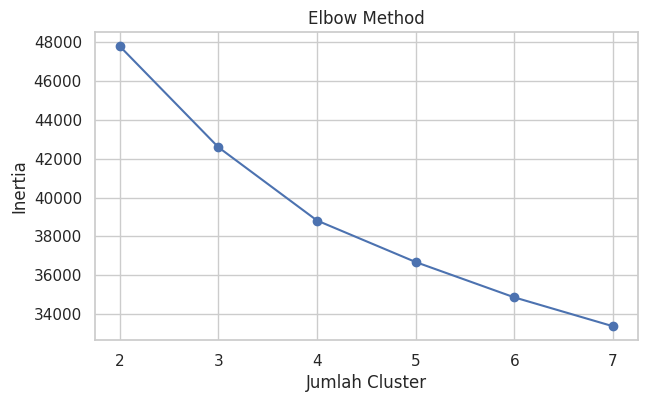

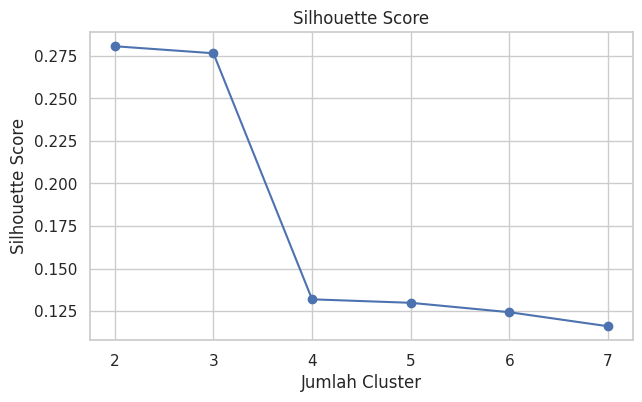

,K,Inertia,Silhouette Score
0,2,47800.049189,0.280675
1,3,42592.434443,0.276556
2,4,38816.792294,0.131908
3,5,36676.887524,0.129861
4,6,34856.569827,0.124334
5,7,33368.097039,0.116076


In [ ]:
# Clustering memakai fitur yang sudah dipilih, tanpa kolom target.

X_cluster = preprocessor.fit_transform(X)

# Mencari jumlah cluster terbaik dengan inertia dan silhouette score
inertias = []
silhouette_scores = []
K_range = range(2, 8)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_cluster)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_cluster, labels))

plt.figure(figsize=(7,4))
plt.plot(list(K_range), inertias, marker='o')
plt.title("Elbow Method")
plt.xlabel("Jumlah Cluster")
plt.ylabel("Inertia")
plt.show()

plt.figure(figsize=(7,4))
plt.plot(list(K_range), silhouette_scores, marker='o')
plt.title("Silhouette Score")
plt.xlabel("Jumlah Cluster")
plt.ylabel("Silhouette Score")
plt.show()

cluster_result = pd.DataFrame({
    "K": list(K_range),
    "Inertia": inertias,
    "Silhouette Score": silhouette_scores
})

display(cluster_result)

In [ ]:
# Jumlah cluster terbaik diambil dari nilai silhouette score tertinggi.
best_k = cluster_result.sort_values(by="Silhouette Score", ascending=False).iloc[0]["K"]
best_k = int(best_k)

kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(X_cluster)

df_clustered = df_capped.copy()
df_clustered["Cluster"] = cluster_labels

print("Jumlah cluster terbaik berdasarkan silhouette:", best_k)
display(df_clustered[["Cluster", target_col]].head())

print("Distribusi cluster:")
display(df_clustered["Cluster"].value_counts())

Jumlah cluster terbaik berdasarkan silhouette: 2


,Cluster,Target
0,1,Dropout
1,0,Graduate
2,1,Dropout
3,0,Graduate
4,0,Graduate


Distribusi cluster:


,count
Cluster,
0,3518
1,906


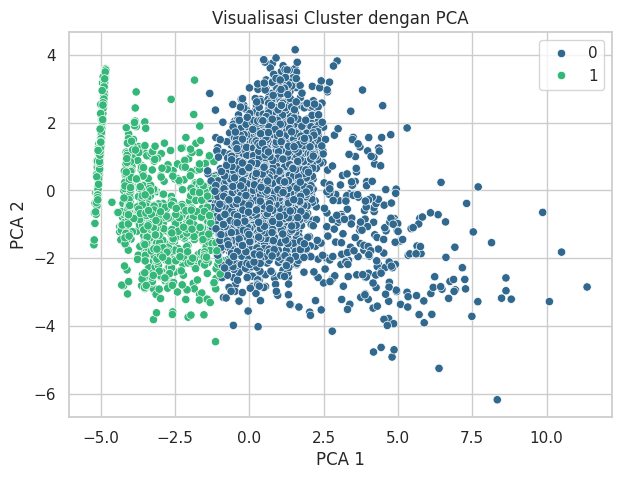

In [ ]:
# PCA dipakai agar hasil cluster bisa divisualisasikan dalam 2 dimensi.
pca = PCA(n_components=2, random_state=42)
X_cluster_pca = pca.fit_transform(
    X_cluster.toarray() if hasattr(X_cluster, "toarray") else X_cluster
)

plt.figure(figsize=(7,5))
sns.scatterplot(x=X_cluster_pca[:,0], y=X_cluster_pca[:,1], hue=cluster_labels, palette="viridis")
plt.title("Visualisasi Cluster dengan PCA")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

## 14. Regression

Pada bagian regression, saya mencoba memprediksi nilai numerik yaitu `Curricular_units_2nd_sem_grade`. Bagian ini menunjukkan bahwa dataset juga bisa digunakan untuk prediksi nilai, bukan hanya klasifikasi status mahasiswa

In [ ]:
# Untuk regression, target yang diprediksi adalah Curricular_units_2nd_sem_grade.
# Kolom ini dipilih karena berupa numerik dan masih berhubungan dengan performa akademik.

regression_target = "Curricular_units_2nd_sem_grade"

reg_df = df_capped.copy()

# Kolom target klasifikasi dan target regression tidak dimasukkan ke fitur.
X_reg = reg_df.drop(columns=[target_col, regression_target])
y_reg = reg_df[regression_target]

# Karena fitur selain Target sudah numerik, preprocessing regression dibuat sederhana.
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg, y_reg,
    test_size=0.2,
    random_state=42
)

reg_preprocessor = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

reg_models = {
    "Linear Regression": LinearRegression(),
    "Random Forest Regressor": RandomForestRegressor(random_state=42)
}

for name, model in reg_models.items():
    reg_pipeline = Pipeline(steps=[
        ('preprocess', reg_preprocessor),
        ('model', model)
    ])

    reg_pipeline.fit(X_reg_train, y_reg_train)
    y_reg_pred = reg_pipeline.predict(X_reg_test)

    mae = mean_absolute_error(y_reg_test, y_reg_pred)
    rmse = np.sqrt(mean_squared_error(y_reg_test, y_reg_pred))
    r2 = r2_score(y_reg_test, y_reg_pred)

    print("="*50)
    print(name)
    print("MAE :", round(mae, 4))
    print("RMSE:", round(rmse, 4))
    print("R2  :", round(r2, 4))

Linear Regression
MAE : 0.8892
RMSE: 1.2385
R2  : 0.7799
Random Forest Regressor
MAE : 0.5906
RMSE: 0.8766
R2  : 0.8897


## 15. Classification

Classification menjadi bagian utama karena target pada dataset ini adalah status mahasiswa, yaitu `Graduate`, `Dropout`, atau `Enrolled`. Saya membandingkan beberapa algoritma, lalu memilih model dengan akurasi terbaik.

Model: Logistic Regression
Accuracy: 0.7525

Classification Report:
              precision    recall  f1-score   support

     Dropout       0.77      0.74      0.75       284
    Enrolled       0.52      0.32      0.40       159
    Graduate       0.79      0.92      0.85       442

    accuracy                           0.75       885
   macro avg       0.69      0.66      0.67       885
weighted avg       0.73      0.75      0.74       885



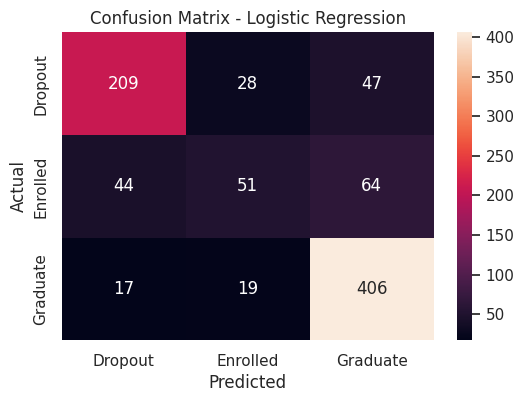

Model: Decision Tree
Accuracy: 0.6633

Classification Report:
              precision    recall  f1-score   support

     Dropout       0.69      0.66      0.67       284
    Enrolled       0.31      0.35      0.33       159
    Graduate       0.79      0.78      0.78       442

    accuracy                           0.66       885
   macro avg       0.60      0.59      0.60       885
weighted avg       0.67      0.66      0.67       885



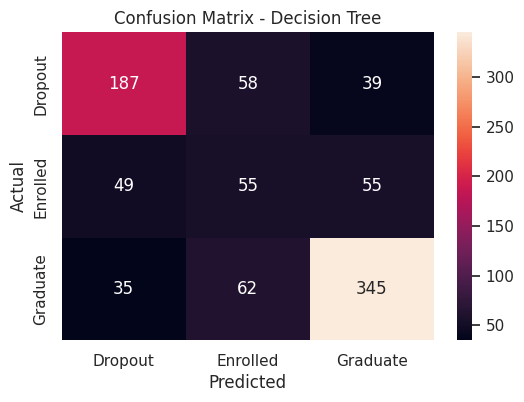

Model: Random Forest
Accuracy: 0.7751

Classification Report:
              precision    recall  f1-score   support

     Dropout       0.80      0.76      0.78       284
    Enrolled       0.62      0.35      0.45       159
    Graduate       0.79      0.94      0.86       442

    accuracy                           0.78       885
   macro avg       0.74      0.68      0.70       885
weighted avg       0.76      0.78      0.76       885



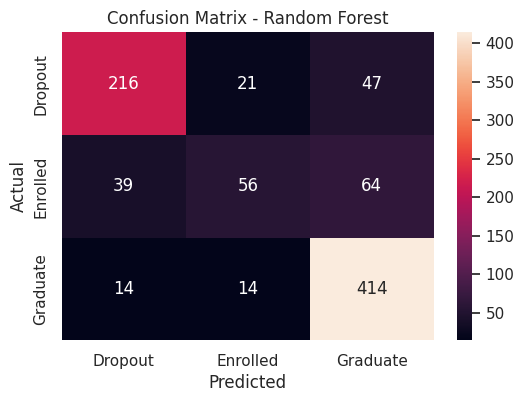

,Model,Accuracy
2,Random Forest,0.775141
0,Logistic Regression,0.752542
1,Decision Tree,0.663277


Model terbaik: Random Forest
Accuracy terbaik: 0.7751


In [ ]:
classification_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
}

classification_results = []

best_model_name = None
best_accuracy = 0
best_pipeline = None

for name, model in classification_models.items():
    clf_pipeline = Pipeline(steps=[
        ('preprocess', preprocessor),
        ('model', model)
    ])

    clf_pipeline.fit(X_train, y_train)
    y_pred = clf_pipeline.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    classification_results.append({
        "Model": name,
        "Accuracy": acc
    })

    print("="*70)
    print("Model:", name)
    print("Accuracy:", round(acc, 4))
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    plt.figure(figsize=(6,4))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d',
                xticklabels=clf_pipeline.classes_,
                yticklabels=clf_pipeline.classes_)
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    if acc > best_accuracy:
        best_accuracy = acc
        best_model_name = name
        best_pipeline = clf_pipeline

classification_results_df = pd.DataFrame(classification_results).sort_values(by="Accuracy", ascending=False)
display(classification_results_df)

print("Model terbaik:", best_model_name)
print("Accuracy terbaik:", round(best_accuracy, 4))

In [ ]:
# Cross validation dipakai untuk melihat apakah performa model cukup stabil.
cv_scores = cross_val_score(best_pipeline, X, y, cv=5, scoring='accuracy')

print("Cross Validation Scores:", cv_scores)
print("Rata-rata CV Accuracy:", round(cv_scores.mean(), 4))
print("Standar Deviasi:", round(cv_scores.std(), 4))

Cross Validation Scores: [0.77740113 0.78757062 0.76271186 0.77175141 0.75791855]
Rata-rata CV Accuracy: 0.7715
Standar Deviasi: 0.0105


In [ ]:
# Contoh prediksi memakai satu data dari data test.
sample_data = X_test.iloc[[0]]
actual_label = y_test.iloc[0]
prediction = best_pipeline.predict(sample_data)[0]
prediction_proba = best_pipeline.predict_proba(sample_data)

print("Data contoh:")
display(sample_data)

print("Label asli:", actual_label)
print("Hasil prediksi model:", prediction)

proba_df = pd.DataFrame(prediction_proba, columns=best_pipeline.classes_)
display(proba_df)

Data contoh:


,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_1st_sem_approved,Curricular_units_1st_sem_grade,Admission_grade,Tuition_fees_up_to_date,Curricular_units_2nd_sem_evaluations,Previous_qualification_grade,Age_at_enrollment,Curricular_units_1st_sem_evaluations,Course,Father's_occupation,Mother's_occupation,GDP,Curricular_units_2nd_sem_enrolled
1853,6,14.666667,6,14.0,160.0,1,7,160.0,20.0,7,9003,10,2,1.79,6


Label asli: Graduate
Hasil prediksi model: Graduate


,Dropout,Enrolled,Graduate
0,0.21,0.05,0.74


# TRAINING MODEL


In [ ]:
!pip -q install scikit-learn joblib

import pandas as pd
import joblib

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Load dataset
df = pd.read_csv("data.csv", sep=";")


df.columns = df.columns.str.strip()

simple_features = [
    "Admission grade",
    "Previous qualification (grade)",
    "Age at enrollment",
    "Tuition fees up to date",
    "Curricular units 1st sem (enrolled)",
    "Curricular units 1st sem (approved)",
    "Curricular units 1st sem (grade)",
    "Curricular units 2nd sem (enrolled)",
    "Curricular units 2nd sem (approved)",
    "Curricular units 2nd sem (grade)"
]

target_column = "Target"

X = df[simple_features]
y = df[target_column]

# Split data training dan testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Pipeline: isi missing value, scaling, lalu model classification
simple_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight="balanced"
    ))
])

# Training model
simple_model.fit(X_train, y_train)

# Evaluasi model
y_pred = simple_model.predict(X_test)

print("Akurasi model sederhana:", round(accuracy_score(y_test, y_pred) * 100, 2), "%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Simpan model dan fitur baru
joblib.dump(simple_model, "student_status_simple_model.pkl")
joblib.dump(simple_features, "simple_features.pkl")

print("File model: student_status_simple_model.pkl")
print("File fitur: simple_features.pkl")

Akurasi model sederhana: 75.14 %

Classification Report:
              precision    recall  f1-score   support

     Dropout       0.77      0.75      0.76       284
    Enrolled       0.47      0.30      0.36       159
    Graduate       0.80      0.92      0.85       442

    accuracy                           0.75       885
   macro avg       0.68      0.65      0.66       885
weighted avg       0.73      0.75      0.73       885


Confusion Matrix:
[[213  29  42]
 [ 52  47  60]
 [ 12  25 405]]
File model: student_status_simple_model.pkl
File fitur: simple_features.pkl
